Gray Scale Frame Matrix

In [ ]:
import cv2
import numpy as np

# Load the video
video_path = "video.mp4"   # change to your video file path
cap = cv2.VideoCapture(video_path)

# Read one frame
ret, frame = cap.read()

if ret:
    # Convert frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Print grayscale matrix values
    print("Grayscale Frame Matrix:\n")
    print(gray)

else:
    print("Error: Could not read frame from video.")

# Release video
cap.release()

Grayscale Frame Matrix:

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


Video capturing

In [ ]:
from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode

def record_video(filename='video.webm'):

    js = Javascript('''
    async function recordVideo() {
        const div = document.createElement('div');
        const start = document.createElement('button');
        const stop = document.createElement('button');

        start.textContent = "Start Recording";
        stop.textContent = "Stop Recording";

        div.appendChild(start);
        div.appendChild(stop);

        const video = document.createElement('video');
        video.style.display = 'block';
        div.appendChild(video);

        document.body.appendChild(div);

        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        video.srcObject = stream;
        await video.play();

        let recorder = new MediaRecorder(stream);
        let chunks = [];

        recorder.ondataavailable = e => chunks.push(e.data);

        start.onclick = () => recorder.start();

        stop.onclick = () => recorder.stop();

        await new Promise(resolve => recorder.onstop = resolve);

        const blob = new Blob(chunks);
        const reader = new FileReader();

        return await new Promise(resolve => {
            reader.onloadend = () => resolve(reader.result);
            reader.readAsDataURL(blob);
        });
    }
    ''')

    display(js)

    data = eval_js('recordVideo()')
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [ ]:
video_file = record_video()
print("Saved to:", video_file)

<IPython.core.display.Javascript object>

Saved to: video.webm


Original Frame Matrix:

[[[223 193 153]
  [223 193 153]
  [223 191 156]
  ...
  [ 91  89 101]
  [ 87  84 101]
  [ 85  82  99]]

 [[223 193 153]
  [223 193 153]
  [223 191 156]
  ...
  [ 93  91 103]
  [ 92  89 106]
  [ 91  88 105]]

 [[219 192 156]
  [219 192 156]
  [219 191 159]
  ...
  [ 88  87  97]
  [ 90  88 100]
  [ 91  89 101]]

 ...

 [[197 199 192]
  [200 202 195]
  [201 201 192]
  ...
  [ 39  99 122]
  [ 36  96 119]
  [ 32  92 115]]

 [[207 199 187]
  [210 202 190]
  [209 203 186]
  ...
  [ 41 101 124]
  [ 39  99 122]
  [ 29  89 112]]

 [[213 205 193]
  [216 208 196]
  [214 208 191]
  ...
  [ 43 103 126]
  [ 41 101 124]
  [ 27  87 110]]]


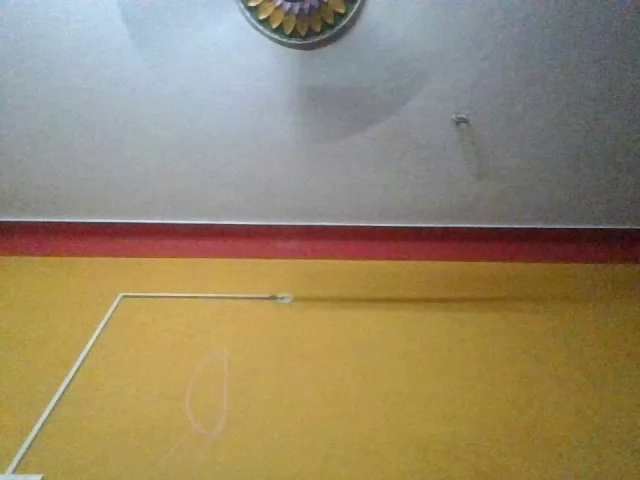


Grayscale Frame Matrix:

[[184 184 184 ...  93  89  87]
 [184 184 184 ...  95  94  93]
 [184 184 185 ...  90  92  93]
 ...
 [197 200 198 ...  99  96  92]
 [196 199 199 ... 101  99  89]
 [202 205 204 ... 103 101  87]]


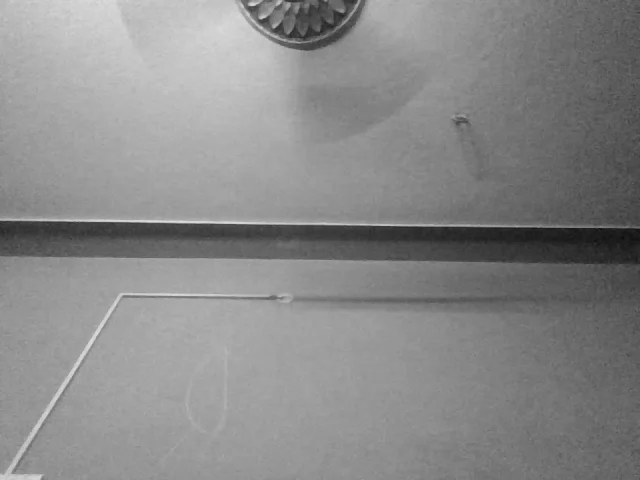

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load the video
video_path = "video.webm"   # change to your video path
cap = cv2.VideoCapture(video_path)

# Read one frame
ret, frame = cap.read()

if ret:

    # Print the original frame matrix
    print("Original Frame Matrix:\n")
    print(frame)

    # Show the frame
    cv2_imshow(frame)

    # Convert frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Print grayscale matrix
    print("\nGrayscale Frame Matrix:\n")
    print(gray)

    # Show grayscale frame
    cv2_imshow(gray)

else:
    print("Error: Could not read frame from video.")

# Release video
cap.release()

In [ ]:
!pip install opencv-python

Edge Detection using Canny

In [ ]:
from IPython.display import Javascript, display

display(Javascript("""
async function runEdgeDetection() {

  const div = document.createElement('div');
  const video = document.createElement('video');
  const canvas = document.createElement('canvas');
  const ctx = canvas.getContext('2d');

  div.appendChild(video);
  div.appendChild(canvas);
  document.body.appendChild(div);

  const stream = await navigator.mediaDevices.getUserMedia({video:true});
  video.srcObject = stream;
  await video.play();

  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;

  function processFrame() {
      ctx.drawImage(video,0,0,canvas.width,canvas.height);

      let frame = cv.imread(canvas);
      let gray = new cv.Mat();
      let edges = new cv.Mat();

      cv.cvtColor(frame, gray, cv.COLOR_RGBA2GRAY);
      cv.Canny(gray, edges, 100, 200);

      cv.imshow(canvas, edges);

      frame.delete();
      gray.delete();
      edges.delete();

      requestAnimationFrame(processFrame);
  }

  processFrame();
}

var script = document.createElement('script');
script.src = "https://docs.opencv.org/4.x/opencv.js";
script.onload = runEdgeDetection;
document.body.appendChild(script);
"""))

<IPython.core.display.Javascript object>

Negative Image Using Formula

<IPython.core.display.Javascript object>

Original Matrix:

[[131 127 121 ... 155 154 154]
 [129 126 124 ... 156 156 156]
 [125 125 126 ... 158 157 157]
 ...
 [ 11  11  10 ... 134 137 142]
 [ 14  11   7 ... 137 137 141]
 [ 17  12   7 ... 141 138 138]]

Negative Matrix:

[[124 128 134 ... 100 101 101]
 [126 129 131 ...  99  99  99]
 [130 130 129 ...  97  98  98]
 ...
 [244 244 245 ... 121 118 113]
 [241 244 248 ... 118 118 114]
 [238 243 248 ... 114 117 117]]


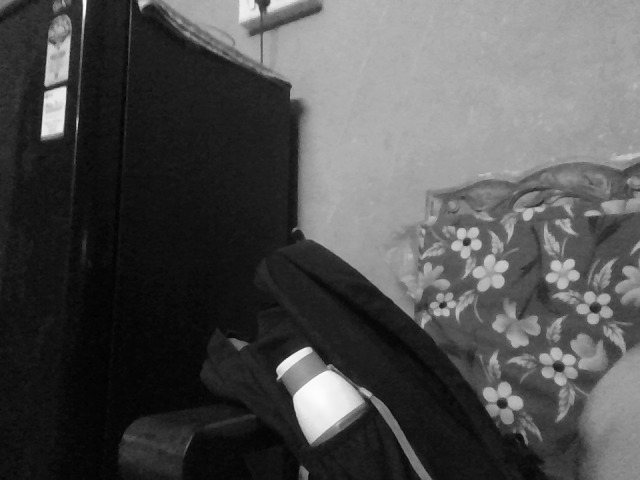

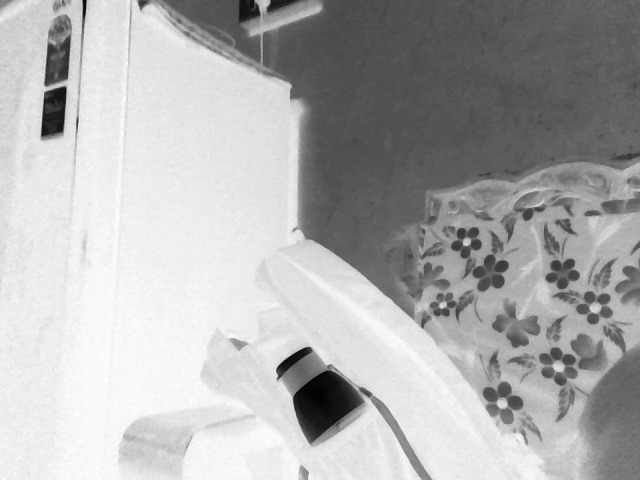

In [18]:
import cv2
import numpy as np
from base64 import b64decode
from IPython.display import Javascript, display
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow

def capture_image():

    js = Javascript('''
    async function takePhoto() {
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({video:true});

        document.body.appendChild(video);
        video.srcObject = stream;
        await video.play();

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        const ctx = canvas.getContext('2d');
        ctx.drawImage(video, 0, 0);

        stream.getTracks().forEach(track => track.stop());
        video.remove();

        return canvas.toDataURL('image/jpeg');
    }
    ''')

    display(js)

    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    img = np.frombuffer(binary, np.uint8)
    frame = cv2.imdecode(img, cv2.IMREAD_COLOR)

    return frame


# Capture frame
frame = capture_image()

# Convert to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Negative image
negative = 255 - gray

print("Original Matrix:\n")
print(gray)

print("\nNegative Matrix:\n")
print(negative)

cv2_imshow(gray)
cv2_imshow(negative)

Detection of Edge Using Gradient Formula

In [ ]:
import cv2
import numpy as np

# Read image
img = cv2.imread("image.jpg")

# Convert image to grayscale
# Edge detection works on intensity values
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Sobel kernel for detecting horizontal edges (Gx)
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Sobel kernel for detecting vertical edges (Gy)
sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

# Convolution operation to compute gradient in x direction
Gx = cv2.filter2D(gray, -1, sobel_x)

# Convolution operation to compute gradient in y direction
Gy = cv2.filter2D(gray, -1, sobel_y)

# Compute gradient magnitude using the formula
# G = sqrt(Gx^2 + Gy^2)
G = np.sqrt(Gx.astype(float)**2 + Gy.astype(float)**2)

# Normalize values to 0-255 range
G = np.uint8(G / G.max() * 255)

# Show results
cv2.imshow("Original Image", gray)
cv2.imshow("Gradient X (Gx)", Gx)
cv2.imshow("Gradient Y (Gy)", Gy)
cv2.imshow("Edge Magnitude", G)

cv2.waitKey(0)
cv2.destroyAllWindows()